# Package loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

/opt/anaconda3/envs/dkrl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Define the path to your CSV file
file_path = 'ASOS-dataset-sample.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)
df = df.drop(columns=["url", "image", "you_might_also_like"])
# print(df)

df_text = df.astype(str).apply(lambda row: ' | '.join(row), axis=1).to_frame(name="text")
print(df_text)

                                                  text
0    Pieces Tall - Short en jean - Bleu | Pieces Ta...
1    Extro & Vert Tall – Oliwkowa kopertowa sukienk...
2    Top con estampado animal y cuello barco de Lip...
3    The North Face Training Flex mid rise leggings...
4    adidas Originals - Sport bh met tie-dye in gee...
..                                                 ...
995  Camisa a cuadros verdes y azules de Jack & Jon...
996  Set de pajarita estampada y pañuelo de bolsill...
997  ASOS EDITION – Transparentes Maxikleid in Blau...
998  ASOS DESIGN - Langærmet oneshoulder-midikjole ...
999  Napapijri - Box - Sort dynejakke  | Napapijri ...

[1000 rows x 1 columns]


In [13]:
df_text.to_csv('ASOS-text.csv', index=False, header=True)

In [14]:
# generate embeddings for the headlines
from sentence_transformers import SentenceTransformer

# Load the SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L12-v2')

# Define a function to compute embeddings
def compute_embeddings(questions):
    return model.encode(questions, convert_to_tensor=True).cpu().numpy()

In [15]:
# Compute embeddings for unique headlines
len(compute_embeddings("unique_headlines"))

384

In [19]:
# Compute embeddings for all unique headlines
embeddings = compute_embeddings(df_text["text"].tolist())

# Save to a CSV file 
np.savetxt('asos-embeddings.csv', embeddings, delimiter=',')

# Compute the correlation matrix

In [20]:
embeddings = np.loadtxt('asos-embeddings.csv', delimiter=',')

# Compute the correlation matrix
correlation_matrix = np.corrcoef(embeddings)

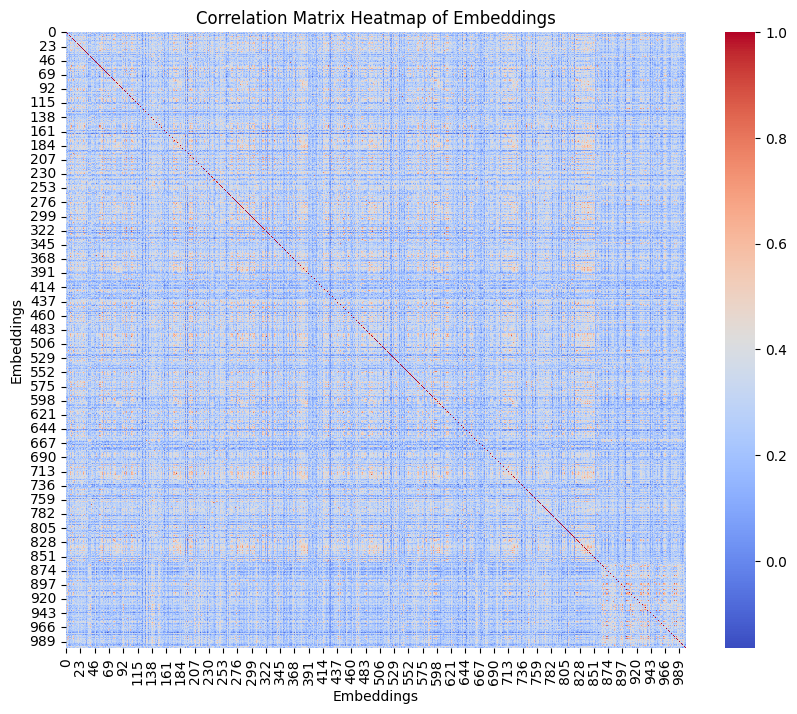

In [21]:
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix Heatmap of Embeddings')
plt.xlabel('Embeddings')
plt.ylabel('Embeddings')
plt.show()